# SUP ML 2 - MODEL

# Libraries

In [ ]:
# gestión de datos
import numpy as np
import pandas as pd

# gráficos
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# modelos
from sklearn.linear_model import Perceptron, SGDClassifier, LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.ensemble import RandomForestClassifier

# metricas
import sklearn.metrics as metrics

# hiperparametrizado
from sklearn.model_selection import GridSearchCV

# interpretabilidad
import shap

# quitar alertas
import warnings
warnings.filterwarnings("ignore")

# para visualizar mas columnas en un df
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
np.random.seed(42)

import pickle

# Carga clean data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_entrenar = pd.read_pickle('/content/drive/MyDrive/DSC-0924-Entregable 2-Buixeda_Urbina_Longobardi_Farres/df_encoded.pkl')

In [ ]:
df_entrenar.head()

,mou,totmrc,da,vceovr,datovr,roam,change_mou,change_rev,drop_vce,drop_dat,blck_vce,blck_dat,unan_vce,unan_dat,plcd_dat,recv_vce,recv_sms,custcare,ccrndmou,threeway,mou_cvce,mou_cdat,mou_rvce,owylis_vce,mouowylisv,iwylis_vce,mouiwylisv,peak_vce,peak_dat,mou_peav,mou_pead,opk_vce,opk_dat,mou_opkv,drop_blk,complete,callfwdv,callwait,churn,months,uniqsubs,actvsubs,asl_flag,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3qty,avg3rev,avg6rev,refurb_new,hnd_price,phones,models,truck,rv,adults,infobase,creditcd,eqpdays,has_kid,new_cell_N,new_cell_U,new_cell_Y,crclscod_A,crclscod_AA,crclscod_B,crclscod_BA,crclscod_CA,crclscod_DA,crclscod_EA,crclscod_OTRO,prizm_social_one_C,prizm_social_one_R,prizm_social_one_S,prizm_social_one_T,prizm_social_one_U,area_ATLANTIC SOUTH AREA,area_CALIFORNIA NORTH AREA,area_CENTRAL/SOUTH TEXAS AREA,area_CHICAGO AREA,area_DALLAS AREA,area_DC/MARYLAND/VIRGINIA AREA,area_GREAT LAKES AREA,area_LOS ANGELES AREA,area_MIDWEST AREA,area_NEW ENGLAND AREA,area_NEW YORK CITY AREA,area_NORTH FLORIDA AREA,area_NORTHWEST/ROCKY MOUNTAIN AREA,area_OHIO AREA,area_OTRA,area_SOUTHWEST AREA,dualband_N,dualband_OTROS,dualband_Y,hnd_webcap_UNKW,hnd_webcap_WC,hnd_webcap_WCMB,marital_M,marital_OTROS,marital_S,marital_U,ethnic_G,ethnic_H,ethnic_N,ethnic_O,ethnic_S,ethnic_U,ethnic_Z,ethnic_otro
0,219.25,22.500000,0.2475,0.0,0.0,0.0,-157.25,-18.997499,0.666667,0.0,0.666667,0.0,6.333333,0.0,0.0,42.333332,0.0,0.000000,0.000000,0.000000,90.643333,0.0,97.176666,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600006,0.0,24.000000,0.0,55.220001,1.333333,45.000000,0.0,0.333333,1.0,61.0,2.0,1.0,0.0,1453.44,4085.00,1602.0,29.660000,83.370003,32.689999,116.0,30.0,38.0,1.0,149.98999,2.0,2.0,0.0,0.0,1.0,1.0,1.0,361.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,482.75,37.424999,0.2475,9.1,0.0,0.0,532.25,50.987499,8.333333,0.0,1.000000,0.0,61.333332,0.0,0.0,69.000000,0.0,1.666667,6.333333,0.333333,189.396667,0.0,55.279999,46.333332,24.216667,6.333333,3.696667,83.666664,0.0,75.333336,0.0,157.000000,0.0,169.343338,9.333333,193.333328,0.0,5.666667,0.0,56.0,1.0,1.0,0.0,2833.88,26367.00,14624.0,51.529999,479.399994,265.890015,158.0,40.0,48.0,1.0,29.98999,7.0,6.0,1.0,1.0,1.0,1.0,1.0,240.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,10.25,16.990000,0.0000,0.0,0.0,0.0,-4.25,0.000000,0.333333,0.0,0.000000,0.0,2.666667,0.0,0.0,0.333333,0.0,0.000000,0.000000,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.333333,6.000000,0.0,0.000000,1.0,58.0,1.0,1.0,0.0,1934.47,24303.05,7888.0,34.540001,433.980011,140.860001,7.0,17.0,17.0,1.0,29.98999,2.0,1.0,0.0,0.0,2.0,1.0,1.0,1504.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,7.50,38.000000,0.0000,0.0,0.0,0.0,-1.50,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,1.333333,0.0,0.000000,0.000000,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.000000,3.666667,0.0,0.000000,0.0,60.0,1.0,1.0,0.0,1941.81,3035.00,1479.0,40.450001,63.230000,30.809999,3.0,38.0,40.0,1.0,29.98999,1.0,1.0,0.0,0.0,4.0,1.0,1.0,1812.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,570.50,71.980003,0.0000,0.0,0.0,0.0,38.50,0.000000,9.666667,0.0,0.666667,0.0,77.000000,0.0,0.0,94.666664,0.0,8.666667,15.000000,0.000000,285.233337,0.0,106.330002,14.666667,10.816667,0.666667,0.366667

# Split X-y

In [ ]:
y = df_entrenar['churn']
X = df_entrenar.drop('churn', axis = 1)

# Distribución del target

In [ ]:
target = df_entrenar['churn']

churn
1.0    50.822901
0.0    49.177099
Name: proportion, dtype: float64


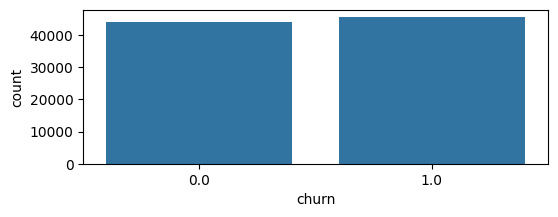

In [ ]:
print(df_entrenar['churn'].value_counts(normalize = True).mul(100))

fig, ax = plt.subplots(figsize = (6, 2))
sns.countplot(data = df_entrenar, x = target)
plt.show()

# Undersampling (*)

**NOTA:** SOLO EN CLASIFICACIÓN cuando el ratio de éxitos está MUY DESBALANCEADO (<10%).

In [ ]:
print(f"NO HACEMOS UNDERSAMPLING YA QUE LOS DATOS NO ESTAN MUY DESBALANCEADOS.")

NO HACEMOS UNDERSAMPLING YA QUE LOS DATOS NO ESTAN MUY DESBALANCEADOS.


FEATURE IMPORTANCE

In [ ]:
df_entrenar.head()

,mou,totmrc,da,vceovr,datovr,roam,change_mou,change_rev,drop_vce,drop_dat,blck_vce,blck_dat,unan_vce,unan_dat,plcd_dat,recv_vce,recv_sms,custcare,ccrndmou,threeway,mou_cvce,mou_cdat,mou_rvce,owylis_vce,mouowylisv,iwylis_vce,mouiwylisv,peak_vce,peak_dat,mou_peav,mou_pead,opk_vce,opk_dat,mou_opkv,drop_blk,complete,callfwdv,callwait,churn,months,uniqsubs,actvsubs,asl_flag,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3qty,avg3rev,avg6rev,refurb_new,hnd_price,phones,models,truck,rv,adults,infobase,creditcd,eqpdays,has_kid,new_cell_N,new_cell_U,new_cell_Y,crclscod_A,crclscod_AA,crclscod_B,crclscod_BA,crclscod_CA,crclscod_DA,crclscod_EA,crclscod_OTRO,prizm_social_one_C,prizm_social_one_R,prizm_social_one_S,prizm_social_one_T,prizm_social_one_U,area_ATLANTIC SOUTH AREA,area_CALIFORNIA NORTH AREA,area_CENTRAL/SOUTH TEXAS AREA,area_CHICAGO AREA,area_DALLAS AREA,area_DC/MARYLAND/VIRGINIA AREA,area_GREAT LAKES AREA,area_LOS ANGELES AREA,area_MIDWEST AREA,area_NEW ENGLAND AREA,area_NEW YORK CITY AREA,area_NORTH FLORIDA AREA,area_NORTHWEST/ROCKY MOUNTAIN AREA,area_OHIO AREA,area_OTRA,area_SOUTHWEST AREA,dualband_N,dualband_OTROS,dualband_Y,hnd_webcap_UNKW,hnd_webcap_WC,hnd_webcap_WCMB,marital_M,marital_OTROS,marital_S,marital_U,ethnic_G,ethnic_H,ethnic_N,ethnic_O,ethnic_S,ethnic_U,ethnic_Z,ethnic_otro
0,219.25,22.500000,0.2475,0.0,0.0,0.0,-157.25,-18.997499,0.666667,0.0,0.666667,0.0,6.333333,0.0,0.0,42.333332,0.0,0.000000,0.000000,0.000000,90.643333,0.0,97.176666,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600006,0.0,24.000000,0.0,55.220001,1.333333,45.000000,0.0,0.333333,1.0,61.0,2.0,1.0,0.0,1453.44,4085.00,1602.0,29.660000,83.370003,32.689999,116.0,30.0,38.0,1.0,149.98999,2.0,2.0,0.0,0.0,1.0,1.0,1.0,361.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,482.75,37.424999,0.2475,9.1,0.0,0.0,532.25,50.987499,8.333333,0.0,1.000000,0.0,61.333332,0.0,0.0,69.000000,0.0,1.666667,6.333333,0.333333,189.396667,0.0,55.279999,46.333332,24.216667,6.333333,3.696667,83.666664,0.0,75.333336,0.0,157.000000,0.0,169.343338,9.333333,193.333328,0.0,5.666667,0.0,56.0,1.0,1.0,0.0,2833.88,26367.00,14624.0,51.529999,479.399994,265.890015,158.0,40.0,48.0,1.0,29.98999,7.0,6.0,1.0,1.0,1.0,1.0,1.0,240.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,10.25,16.990000,0.0000,0.0,0.0,0.0,-4.25,0.000000,0.333333,0.0,0.000000,0.0,2.666667,0.0,0.0,0.333333,0.0,0.000000,0.000000,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.333333,6.000000,0.0,0.000000,1.0,58.0,1.0,1.0,0.0,1934.47,24303.05,7888.0,34.540001,433.980011,140.860001,7.0,17.0,17.0,1.0,29.98999,2.0,1.0,0.0,0.0,2.0,1.0,1.0,1504.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,7.50,38.000000,0.0000,0.0,0.0,0.0,-1.50,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,1.333333,0.0,0.000000,0.000000,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.000000,3.666667,0.0,0.000000,0.0,60.0,1.0,1.0,0.0,1941.81,3035.00,1479.0,40.450001,63.230000,30.809999,3.0,38.0,40.0,1.0,29.98999,1.0,1.0,0.0,0.0,4.0,1.0,1.0,1812.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,570.50,71.980003,0.0000,0.0,0.0,0.0,38.50,0.000000,9.666667,0.0,0.666667,0.0,77.000000,0.0,0.0,94.666664,0.0,8.666667,15.000000,0.000000,285.233337,0.0,106.330002,14.666667,10.816667,0.666667,0.366667

Top 15 features más importantes y sus pesos:
eqpdays            0.205078
months             0.154641
mou                0.071449
hnd_price          0.049835
totmrc             0.048284
change_mou         0.046773
hnd_webcap_WCMB    0.045310
avg3qty            0.037459
mou_peav           0.022531
mou_cvce           0.021152
adjqty             0.020726
models             0.019231
mou_opkv           0.018008
crclscod_EA        0.016624
adjrev             0.015775
dtype: float64


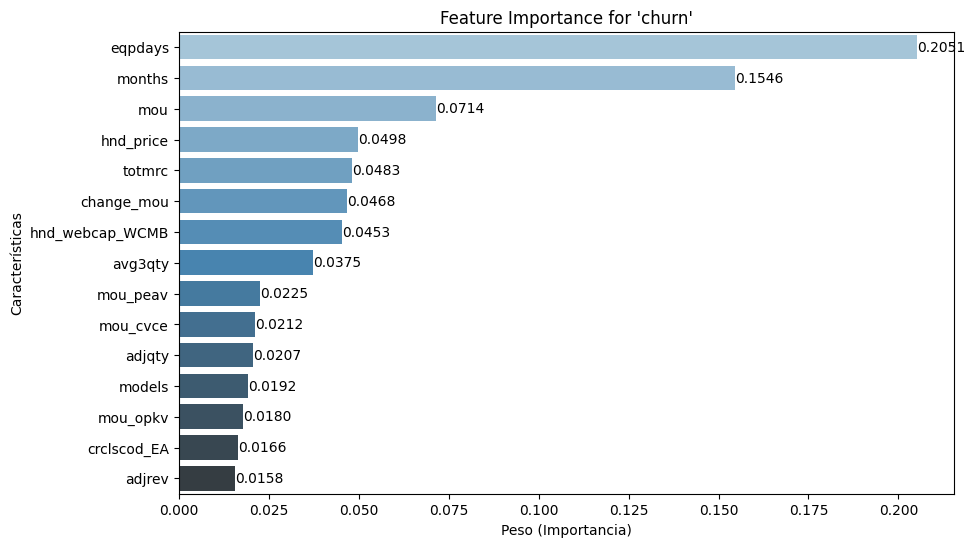

In [ ]:
params = {'random_state': 42, 'n_jobs': 4, 'n_estimators': 100, 'max_depth': 4}

# entrena un RandomForest Classifier
clf = RandomForestClassifier(**params)
clf = clf.fit(X, y)

# plotea las 15 mejores Features importances
num_features = 15
features = clf.feature_importances_
columnas = X.columns
imp = pd.Series(data = features, index = columnas).sort_values(ascending = False)[:num_features]

# imprime el top características con sus pesos
print("Top {} features más importantes y sus pesos:".format(num_features))
print(imp)

# Gráfico con los pesos de las características
plt.figure(figsize = (10, 6))
plt.title("Feature Importance for 'churn'")
sns.barplot(y = imp.index, x = imp.values, palette = "Blues_d", orient = 'h')

# Añade los pesos como etiquetas en el gráfico
for i, (value, name) in enumerate(zip(imp.values, imp.index)):
    plt.text(value, i, f'{value:.4f}', va = 'center', ha = 'left')

plt.xlabel("Peso (Importancia)")
plt.ylabel("Características")
plt.show()

# Split TRAIN-TEST

In [ ]:
# se utilizan 70% de los datos para entrenar el modelo y se guardan 30% de los datos para evaluar el modelo (de forma aleatoria)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [ ]:
# variable target
print('nº observaciones de train:', len(y_train))
print('nº observaciones de test: ', len(y_test))

nº observaciones de train: 62905
nº observaciones de test:  26960


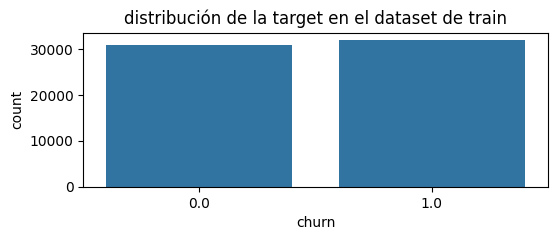

In [ ]:
fig, ax = plt.subplots(figsize = (6, 2))
sns.countplot(x = y_train)
plt.title('distribución de la target en el dataset de train')
plt.show()

In [ ]:
# repartición de la target en el dataset de train
y_train.value_counts(normalize = True).mul(100)

,proportion
churn,
1.0,50.87036
0.0,49.12964


In [ ]:
# repartición de la target en el data set de test
y_test.value_counts(normalize = True).mul(100)

,proportion
churn,
1.0,50.712166
0.0,49.287834


# Rescaling

* NO NECESARIO en modelos de Arboles de Decisión.
* Guardar scaler en el model path.

In [ ]:
# X = total features dataset entrenamiento
X.head(5)

,mou,totmrc,da,vceovr,datovr,roam,change_mou,change_rev,drop_vce,drop_dat,blck_vce,blck_dat,unan_vce,unan_dat,plcd_dat,recv_vce,recv_sms,custcare,ccrndmou,threeway,mou_cvce,mou_cdat,mou_rvce,owylis_vce,mouowylisv,iwylis_vce,mouiwylisv,peak_vce,peak_dat,mou_peav,mou_pead,opk_vce,opk_dat,mou_opkv,drop_blk,complete,callfwdv,callwait,months,uniqsubs,actvsubs,asl_flag,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3qty,avg3rev,avg6rev,refurb_new,hnd_price,phones,models,truck,rv,adults,infobase,creditcd,eqpdays,has_kid,new_cell_N,new_cell_U,new_cell_Y,crclscod_A,crclscod_AA,crclscod_B,crclscod_BA,crclscod_CA,crclscod_DA,crclscod_EA,crclscod_OTRO,prizm_social_one_C,prizm_social_one_R,prizm_social_one_S,prizm_social_one_T,prizm_social_one_U,area_ATLANTIC SOUTH AREA,area_CALIFORNIA NORTH AREA,area_CENTRAL/SOUTH TEXAS AREA,area_CHICAGO AREA,area_DALLAS AREA,area_DC/MARYLAND/VIRGINIA AREA,area_GREAT LAKES AREA,area_LOS ANGELES AREA,area_MIDWEST AREA,area_NEW ENGLAND AREA,area_NEW YORK CITY AREA,area_NORTH FLORIDA AREA,area_NORTHWEST/ROCKY MOUNTAIN AREA,area_OHIO AREA,area_OTRA,area_SOUTHWEST AREA,dualband_N,dualband_OTROS,dualband_Y,hnd_webcap_UNKW,hnd_webcap_WC,hnd_webcap_WCMB,marital_M,marital_OTROS,marital_S,marital_U,ethnic_G,ethnic_H,ethnic_N,ethnic_O,ethnic_S,ethnic_U,ethnic_Z,ethnic_otro
0,219.25,22.500000,0.2475,0.0,0.0,0.0,-157.25,-18.997499,0.666667,0.0,0.666667,0.0,6.333333,0.0,0.0,42.333332,0.0,0.000000,0.000000,0.000000,90.643333,0.0,97.176666,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600006,0.0,24.000000,0.0,55.220001,1.333333,45.000000,0.0,0.333333,61.0,2.0,1.0,0.0,1453.44,4085.00,1602.0,29.660000,83.370003,32.689999,116.0,30.0,38.0,1.0,149.98999,2.0,2.0,0.0,0.0,1.0,1.0,1.0,361.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,482.75,37.424999,0.2475,9.1,0.0,0.0,532.25,50.987499,8.333333,0.0,1.000000,0.0,61.333332,0.0,0.0,69.000000,0.0,1.666667,6.333333,0.333333,189.396667,0.0,55.279999,46.333332,24.216667,6.333333,3.696667,83.666664,0.0,75.333336,0.0,157.000000,0.0,169.343338,9.333333,193.333328,0.0,5.666667,56.0,1.0,1.0,0.0,2833.88,26367.00,14624.0,51.529999,479.399994,265.890015,158.0,40.0,48.0,1.0,29.98999,7.0,6.0,1.0,1.0,1.0,1.0,1.0,240.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,10.25,16.990000,0.0000,0.0,0.0,0.0,-4.25,0.000000,0.333333,0.0,0.000000,0.0,2.666667,0.0,0.0,0.333333,0.0,0.000000,0.000000,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.333333,6.000000,0.0,0.000000,58.0,1.0,1.0,0.0,1934.47,24303.05,7888.0,34.540001,433.980011,140.860001,7.0,17.0,17.0,1.0,29.98999,2.0,1.0,0.0,0.0,2.0,1.0,1.0,1504.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,7.50,38.000000,0.0000,0.0,0.0,0.0,-1.50,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,1.333333,0.0,0.000000,0.000000,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.000000,3.666667,0.0,0.000000,60.0,1.0,1.0,0.0,1941.81,3035.00,1479.0,40.450001,63.230000,30.809999,3.0,38.0,40.0,1.0,29.98999,1.0,1.0,0.0,0.0,4.0,1.0,1.0,1812.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,570.50,71.980003,0.0000,0.0,0.0,0.0,38.50,0.000000,9.666667,0.0,0.666667,0.0,77.000000,0.0,0.0,94.666664,0.0,8.666667,15.000000,0.000000,285.233337,0.0,106.330002,14.666667,10.816667,0.666667,0.366667,97.333336,0.0,173.476

In [ ]:
# guardo las columnas en una lista antes de standarizar
# el metodo scaler quita el nombre de las variables, que luego es necesario para la interpretabilidad
variables_entrenadas = X.columns

In [ ]:
# se estandarizan las variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # estandariza y define la regla de estandarización
X_test = scaler.transform(X_test)       # estandariza según la regla definida con el X_train, con la media de X_train

In [ ]:
# Guardar el scaler en formato pickle
scaler_path = '/content/drive/MyDrive/DSC-0924-Entregable 2-Buixeda_Urbina_Longobardi_Farres/scaler.pkl'

with open(scaler_path, 'wb') as file:
    pickle.dump(scaler, file)

# TRAIN-VALIDA

## Torneo de Modelos

* Probamos una colección de modelos con el objetivo de conseguir el mejor rendimiento del modelo en los datos de VALIDACION.

In [ ]:
# añadimos en una lista los modelos que queremos poner a competir

modelos = []
modelos.append(('Perceptron', Perceptron(random_state = 42)))
modelos.append(('SGDClassifier', SGDClassifier(loss = 'log_loss', random_state = 42)))
modelos.append(('GradientBoostingClassifier', GradientBoostingClassifier(random_state = 42)))
modelos.append(('XGBClassifier', XGBClassifier(random_state = 42, verbosity = 0)))
modelos.append(('CatBoostClassifier', CatBoostClassifier(verbose = False, random_seed = 42)))
modelos.append(('LogisticRegression', LogisticRegression(random_state = 42)))

&#x26a0;&#xfe0f;  
**El metodo roc_auc_score requiere probabilidades para calcular el AUC, no predicciones binarias.**  
**Se saca el AUC comparando la target del test real (y_test) con la predicción (y_pred) hecha con PREDIC_PROBA, no con predict.**

In [ ]:
metricas_modelos = pd.DataFrame(columns = ['modelo', 'AUC'])

for nombre, modelo in modelos:

    # entrenamos el modelo
    modelo.fit(X_train, y_train)

    # hacemos la predicción sobre el dataset de test
    # al AUC se saca con predict_proba.
    # para el perceptron, usaremos decision_function, el equivalente del predict_proba para este algoritmo
    if nombre == 'Perceptron':
      y_pred = modelo.decision_function(X_test)
    else:
      y_pred = modelo.predict_proba(X_test)[:, 1]

    # calculamos el AUC
    auc = metrics.roc_auc_score(y_test, y_pred)

    # imprimimos el resultado por modelo
    metricas_modelos = pd.concat([metricas_modelos,
                                  pd.DataFrame({'modelo': nombre, 'AUC': auc}, index = [0])
                                  ])
    print(modelo, auc)

metricas_modelos.sort_values('AUC', ascending = False)

Perceptron(random_state=42) 0.5458536459597505
SGDClassifier(loss='log_loss', random_state=42) 0.5924659164447594
GradientBoostingClassifier(random_state=42) 0.6697619321946813
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...) 0.6701019349345411
<catboost.core.CatBoostClassifier object at 0x7b

,modelo,AUC
0,CatBoostClassifier,0.686778
0,XGBClassifier,0.670102
0,GradientBoostingClassifier,0.669762
0,LogisticRegression,0.624666
0,SGDClassifier,0.592466
0,Perceptron,0.545854


## Hiperparametrizacion

* Utilizar RandomSearch para probar diferentes configuraciones de los parametros del modelo ganador en el torneo de modelos con el objetivo de mejorar el control del overfitting.

In [ ]:
'''from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier

param_grid = {
    'iterations': [200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 10],
    'random_strength': [1, 5, 10],
    'bagging_temperature': [0.5, 1.0, 3.0],
}

model = CatBoostClassifier(verbose=0, random_seed=42)

grid_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    scoring='roc_auc',
    n_iter=50,  # Número de combinaciones aleatorias a probar
    cv=3,  # Validación cruzada
    verbose=1,
    random_state=42
)

grid_search.fit(X_train, y_train)
print("Mejores parámetros:", grid_search.best_params_)'''

# Mejores parámetros: {'random_strength': 1, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 4, 'bagging_temperature': 3.0}

## Modelo final

* Entrenar el modelo final con el algoritmo y los parametros que han funcionado mejor en anteriores experimentos.
* Argumentar la elección.
* Guardar el modelo en model path.

Primero probamos con los parámetros que nos ha dado la hiperparametrización, pero vemos que el resultado final no es mejor que el que hemos conseguido con los parámetros estándar.

In [ ]:
'''# Recuperar los mejores parámetros
best_params = grid_search.best_params_

# Crear y entrenar el modelo con los mejores parámetros
final_model = CatBoostClassifier(
    random_strength=best_params['random_strength'],
    learning_rate=best_params['learning_rate'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    iterations=best_params['iterations'],
    depth=best_params['depth'],
    bagging_temperature=best_params['bagging_temperature'],
    verbose=0,  # Evitar logs extensos
    random_seed=42  # Reproducibilidad
)

# Entrenar el modelo final con todos los datos de entrenamiento
final_model.fit(X_train, y_train)

# hacemos la predicción sobre el dataset de test
y_pred = final_model.predict_proba(X_test)[:, 1]'''

Nos quedamos con los parámetros estándar ya que nos da mejores resultados que el mejor modelo de la hiperparametrizacion que era un 0.67 aproximadamente.

In [ ]:
# creamos el modelo y lo entrenamos con los parámetros estándar
default_model = CatBoostClassifier(
    verbose = 0,
    random_seed = 42
)

# entrenamos el modelo con todos los datos de entrenamiento
default_model.fit(X_train, y_train)

# predicción sobre el dataset de test
y_pred = default_model.predict_proba(X_test)[:, 1]

In [ ]:
# Guardamos el modelo
model_path = '/content/drive/MyDrive/DSC-0924-Entregable 2-Buixeda_Urbina_Longobardi_Farres/catboost_classification.cbm'

default_model.save_model(model_path)
print("MODELO GUARDADO")

MODELO GUARDADO


# TEST

* Evaluación de las métricas de performance en TEST.

In [ ]:
# calculamos el AUC
auc = metrics.roc_auc_score(y_test, y_pred)
print(f"AUC del modelo con parámetros estándar: {auc:.4f}")

AUC del modelo con parámetros estándar: 0.6868


# INTERPRETABILITY

* Analizamos top features del modelo y su peso en el modelo.
* Plotear SHAP values y el impacto positivo/negativo.
* Comentar las top5 features, su impacto en el target y extraer insights.
* Analisis complementarios:
  * Modelos de arboles: Feature Importances, plot de arbol de decision.
  * Modelos lineales: Coeficentes y formula del modelo.

**FEATURE IMPORTANCE**:

Establecemos la semilla random state 42, para asegurar que los resultados sean reproducibles.

n_jobs 4: permite el procesamiento en paralelo para acelerar el cálculo, utilizando 4 núcleos de CPU.

Definimos 100 árboles para mejorar la estabilidad del modelo.

Limitamos la profundidad máxima de los árboles a 4 para evitar el sobreajuste y hacer que el modelo sea mas interpretable.

In [ ]:
# Ploteamos las mejores Features importances
features = default_model.feature_importances_
columnas = X.columns
imp = pd.Series(data = features, index = columnas).sort_values(ascending = False)[:20]
imp # Nos da error a la hora de hacer la grafica, pone que tiene una dimension que no soporta matplotlib
#plt.figure(figsize = (8, 4))
#plt.title("Feature importance '{}'".format(target))
#ax = sns.barplot(y = imp.index, x = imp.values, palette = "Blues_d", orient = 'h')
#plt.show()

,0
eqpdays,6.952150
months,6.664236
mou,6.473452
change_mou,6.118306
totmrc,4.506570
change_rev,3.605258
avgqty,2.717546
vceovr,2.671532
avgmou,2.266562
hnd_price,2.225322


La "Feature importance" nos muestra qué características son más relevantes para las predicciones globales del modelo. Se basa en la contribución global al modelo. Las top 5 son:
1. eqpdays:  Number of days (age) of current equipment
2. months:  Total number of months in service
3. mou:  Mean number of monthly minutes of use
4. hnd_price:  Current handset price
5. totmrc:  Mean total monthly recurring charge

Con Feature Importance no es posible obtener directamente el impacto positivo o negativo de las características, ya que esta métrica mide la importancia global de una característica en el modelo sin diferenciar si su influencia es positiva o negativa para una predicción específica.

Para obtener el impacto positivo o negativo de las características en el churn, usaremos SHAP values

**SHAP VALUES**:



Los SHAP values, a diferencia de las "feature importance" nos explica el impacto de cada característica en una predicción específica. Permite analizar cómo cada característica afecta el modelo en diferentes regiones del espacio de datos.
Se basa en teoria de juegos.

In [ ]:
# creamos un dataframe con los datos de X_test y las variables como columnas (por eso las guardamos antes)
df_X_test = pd.DataFrame(X_test, columns=variables_entrenadas)

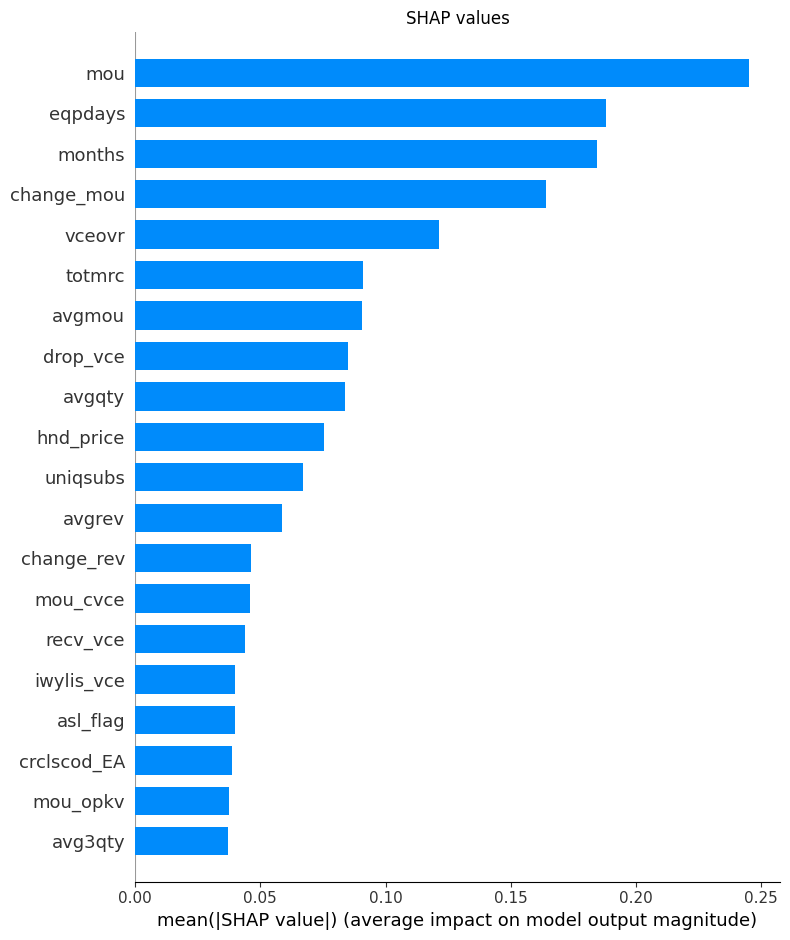

In [ ]:
# SHAP value: peso en el output final
explainer = shap.TreeExplainer(default_model)
shap_values = explainer.shap_values(df_X_test)
plt.title('SHAP values')
shap.summary_plot(shap_values, df_X_test, plot_type = "bar", max_display = 20)

Los SHAP values nos indican ademas el sentido del impacto que tiene la variable en la predicción (positivo/negativo).

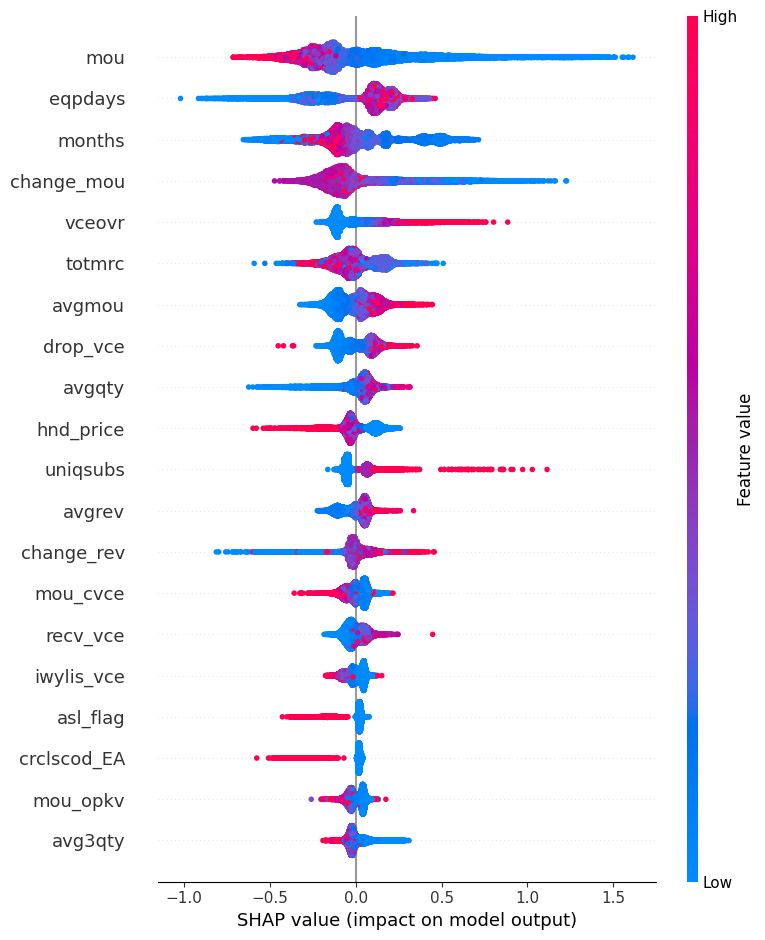

In [ ]:
shap.summary_plot(shap_values, df_X_test)

Las caracteristicas en la parte superior son las más importantes a nivel global, es decir, tienen un mayor impacto en las predicciones.

- Si los puntos rojos (valores altos) están hacia la derecha (valores SHAP positivos), significa que un valor alto de esa característica aumenta la probabilidad de la clase objetivo.

- Si los puntos rojos están hacia la izquierda (valores SHAP negativos), significa que un valor alto de esa característica disminuye la probabilidad de la clase objetivo.

En este caso:

1. **mou**:  Mean number of monthly minutes of use.

Esta es la característica más relevante en el modelo. Un valor elevado de mou, es decir, cuanto mayor sea el número de minutos de uso mensual de un cliente, disminuye la probabilidad de churn. Esto sugiere que los clientes que utilizan más el servicio tienen más probabilidades de permanecer, lo que podría reflejar una mayor satisfacción o dependencia del servicio.


2. **eqpdays**: Number of days (age) of current equipment

Ocupa la segunda posición en términos de importancia. Los puntos rojos a la derecha del gráfico SHAP, que indican valores positivos de SHAP (hasta 0.5), sugieren que los clientes con equipos más antiguos tienen una mayor probabilidad de abandonar el servicio. Por el contrario, los clientes con equipos más nuevos tienen una menor probabilidad de churn, lo que implica que la modernización de equipos podría ser una estrategia efectiva para reducir el churn.

3. **months**:  Total number of months in service

Los clientes con más tiempo en el servicio parecen tener más probabilidades de abandonar el servicio, mientras que los clientes más nuevos tienen una menor probabilidad de churn.
Este patrón indica que los clientes a largo plazo podrían sentirse menos satisfechos o que las ofertas de fidelización y beneficios adicionales son cruciales para retenerlos. Se debe considerar implementar estrategias de fidelización específicas para estos clientes, tales como incentivos o mejoras continuas en el servicio.

4. **change_mou**:  Percentage change in monthly minutes of use vs previous three month average

Los puntos rojos a la izquierda indican que una disminución en el uso de minutos mensuales (un valor negativo en change_mou) tiene un impacto positivo en la probabilidad de churn, es decir, si un cliente reduce su consumo, es más probable que abandone el servicio. En contraste, un aumento en el uso de minutos se asocia con una menor probabilidad de churn. Esto sugiere que bajas en la actividad de uso podrían ser una señal temprana de desinterés y potencial abandono, mientras que un aumento en la actividad puede ser indicativo de una mayor fidelización.

5. **vceovr**:  Mean revenue of voice overage

Los valores positivos de SHAP para esta característica indican que cuando un cliente genera más ingresos a través de minutos adicionales, lo cual ocurre cuando sobrepasan su plan de minutos, aumenta la probabilidad de churn. Esto puede ser un indicativo de que el cliente está insatisfecho con el plan actual y podría estar considerando cambiarse a un competidor. Una posible solución sería ofrecer planes de voz más adecuados o flexibles que reduzcan la necesidad de pagar por exceso de minutos, mejorando así la satisfacción del cliente.